In [ ]:
# K-Means Clustering on Climate Dataset
# Simple implementation with Elbow Method

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)


In [ ]:
# Load the dataset
# Upload your CSV file in Colab using the file upload button
# Then update the filename below
df = pd.read_excel('/content/countries_data.csv.xlsx')

# Display first few rows
print("Dataset Preview:")
print(df.head(10))
print(f"\nDataset Shape: {df.shape}")
print(f"\nColumn Names: {df.columns.tolist()}")
print(f"\nMissing Values:\n{df.isnull().sum()}")

Dataset Preview:
               country  child_mort  exports  health  imports  income  \
0          Afghanistan        90.2     10.0    7.58     44.9    1610   
1              Albania        16.6     28.0    6.55     48.6    9930   
2              Algeria        27.3     38.4    4.17     31.4   12900   
3               Angola       119.0     62.3    2.85     42.9    5900   
4  Antigua and Barbuda        10.3     45.5    6.03     58.9   19100   
5            Argentina        14.5     18.9    8.10     16.0   18700   
6              Armenia        18.1     20.8    4.40     45.3    6700   
7            Australia         4.8     19.8    8.73     20.9   41400   
8              Austria         4.3     51.3   11.00     47.8   43200   
9           Azerbaijan        39.2     54.3    5.88     20.7   16000   

   inflation  life_expec  total_fer   gdpp  
0      9.440        56.2       5.82    553  
1      4.490        76.3       1.65   4090  
2     16.100        76.5       2.89   4460  
3     22.4

In [ ]:
# Prepare data for clustering
# Select only numerical features (exclude 'country' as it's not numerical for clustering)
features = ['child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']

X = df[features]

# Handle any missing values if present
X = X.dropna()

print(f"\nFeatures used for clustering: {features}")
print(f"Data shape after cleaning: {X.shape}")


Features used for clustering: ['child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']
Data shape after cleaning: (99, 9)



ELBOW METHOD - Finding Optimal K
K=2: Inertia = 610.66
K=3: Inertia = 474.74
K=4: Inertia = 397.04
K=5: Inertia = 348.59
K=6: Inertia = 316.46
K=7: Inertia = 281.45
K=8: Inertia = 258.40
K=9: Inertia = 226.53
K=10: Inertia = 212.17


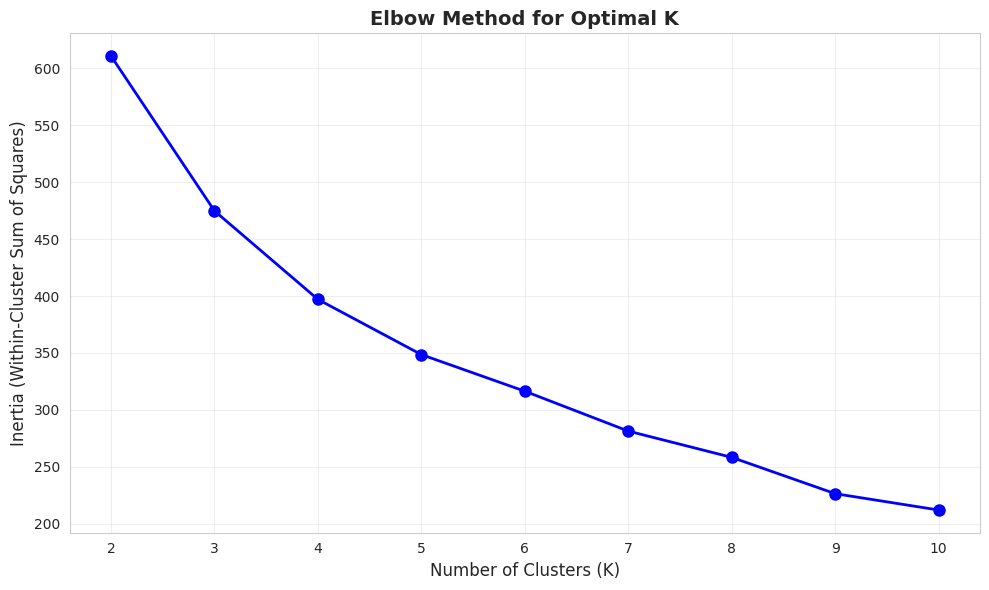

In [ ]:
# Standardize the features (important for k-means!)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\n" + "="*50)
print("ELBOW METHOD - Finding Optimal K")
print("="*50)

# Elbow Method
inertias = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    print(f"K={k}: Inertia = {kmeans.inertia_:.2f}")

# Plot Elbow Curve
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=12)
plt.title('Elbow Method for Optimal K', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(K_range)
plt.tight_layout()
plt.show()



Applying K-Means with K=4

Cluster Distribution:
cluster
0    28
1    49
2    20
3     2
Name: count, dtype: int64

Cluster Centers (Original Scale):
           child_mort  exports  health  imports    income  inflation  \
Cluster 0      100.51    30.32    5.98    46.15   3635.04       9.25   
Cluster 1       22.04    40.54    6.34    46.32  12308.57       6.94   
Cluster 2        5.40    47.17    8.66    41.41  41215.00       2.54   
Cluster 3        4.80   164.00    8.21   148.00  60000.00       3.72   

           life_expec  total_fer      gdpp  
Cluster 0       57.93       5.06   1789.21  
Cluster 1       72.94       2.26   6365.80  
Cluster 2       79.80       1.83  38935.00  
Cluster 3       80.80       1.50  63050.00  

Cluster Statistics

Cluster 0:
       child_mort  exports  health  imports    income  inflation  life_expec  \
count       28.00    28.00   28.00    28.00     28.00      28.00       28.00   
mean       100.51    30.32    5.98    46.15   3635.04       9.25       

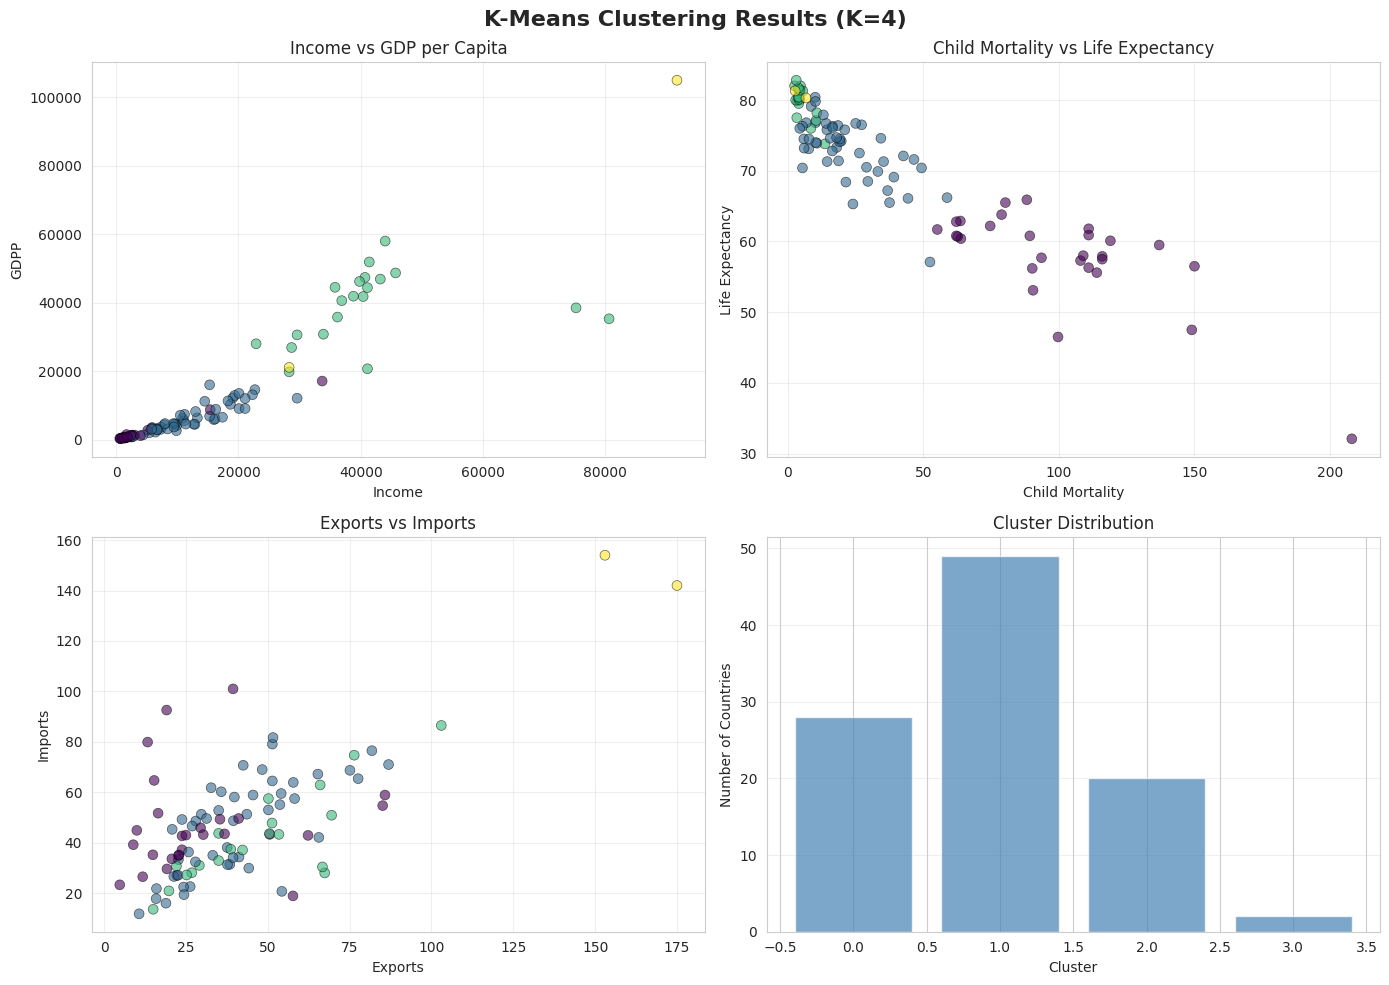


✓ Results saved to '/content/countries_data.csv.xlsx'


In [ ]:
# Based on elbow curve, choose optimal K (you can modify this)
optimal_k = 4  # Change this based on your elbow curve

print(f"\n{'='*50}")
print(f"Applying K-Means with K={optimal_k}")
print("="*50)

# Apply K-Means with optimal K
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['cluster'] = kmeans_final.fit_predict(X_scaled)

# Display cluster statistics
print(f"\nCluster Distribution:")
print(df['cluster'].value_counts().sort_index())

print(f"\nCluster Centers (Original Scale):")
cluster_centers = scaler.inverse_transform(kmeans_final.cluster_centers_)
centers_df = pd.DataFrame(cluster_centers, columns=features)
centers_df.index = [f'Cluster {i}' for i in range(optimal_k)]
print(centers_df.round(2))

# Statistical summary by cluster
print(f"\n{'='*50}")
print("Cluster Statistics")
print("="*50)
for i in range(optimal_k):
    print(f"\nCluster {i}:")
    print(df[df['cluster'] == i][features].describe().round(2))

# Visualizations using actual dataset features
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'K-Means Clustering Results (K={optimal_k})', fontsize=16, fontweight='bold')

# Plot 1: Income vs GDPP
axes[0, 0].scatter(df['income'], df['gdpp'], c=df['cluster'],
                   cmap='viridis', s=50, alpha=0.6, edgecolors='black', linewidth=0.5)
axes[0, 0].set_xlabel('Income')
axes[0, 0].set_ylabel('GDPP')
axes[0, 0].set_title('Income vs GDP per Capita')
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Child Mortality vs Life Expectancy
axes[0, 1].scatter(df['child_mort'], df['life_expec'], c=df['cluster'],
                   cmap='viridis', s=50, alpha=0.6, edgecolors='black', linewidth=0.5)
axes[0, 1].set_xlabel('Child Mortality')
axes[0, 1].set_ylabel('Life Expectancy')
axes[0, 1].set_title('Child Mortality vs Life Expectancy')
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Exports vs Imports
axes[1, 0].scatter(df['exports'], df['imports'], c=df['cluster'],
                   cmap='viridis', s=50, alpha=0.6, edgecolors='black', linewidth=0.5)
axes[1, 0].set_xlabel('Exports')
axes[1, 0].set_ylabel('Imports')
axes[1, 0].set_title('Exports vs Imports')
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Cluster sizes
cluster_counts = df['cluster'].value_counts().sort_index()
axes[1, 1].bar(cluster_counts.index, cluster_counts.values, color='steelblue', alpha=0.7)
axes[1, 1].set_xlabel('Cluster')
axes[1, 1].set_ylabel('Number of Countries')
axes[1, 1].set_title('Cluster Distribution')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Save results
df.to_csv('/content/countries_data.csv.xlsx', index=False)
print(f"\n✓ Results saved to '/content/countries_data.csv.xlsx'")